In [12]:
import os
import json
import pandas as pd
import numpy as np
import glob

# Define the root directory
root = rf"/Users/ck696/Documents/GitHub/univearth_acl"
root_dir = 'results_2511'

# List to store the extracted data
all_records = []

def get_question_index(filename):
    """Extract question index from filename."""
    if filename.endswith('.json'):
        return int(filename.split("_")[1].split(".json")[0])
    else:
        return None
    
ref_dataset = pd.read_csv(root + "/dataset/2025_icmlw_univearth.csv")
    
def get_modality_from_question(question):

    row = ref_dataset[ref_dataset['Question'] == question]
    if len(row) > 0 and row.iloc[0]["Modality"] is not np.nan:
        modality = row.iloc[0]["Modality"].lower()
    else:
        return False

    if "sentinel" in modality:
        return "sentinel"
    elif "landsat" in modality:
        return "landsat"
    elif "modis" in modality:
        return "modis"
    elif "viirs" in modality:
        return "viirs"
    else:
        return "unknown"
        

folder_dir = "/Users/ck696/Documents/GitHub/univearth_acl/results_2511/zero_shot+specific/python/gemini-2.5-pro+gemini-2.5-flash__v1"
x = os.listdir(folder_dir)
indices_for_documentation = [get_question_index(x) for x in x]

# Walk through the directory structure
# We assume structure: results_2511/strategy/language/model_folder/json_file
for root, dirs, files in os.walk(root_dir):
    print("Processing directory:", root)
    for file in files:

        if file.endswith('.json'):

            if get_question_index(file) not in indices_for_documentation:
                continue

            file_path = os.path.join(root, file)
            
            if "claude-sonnet-4-5-20250929" not in root and "gemini-2.5-pro" not in root:
                continue

            if "gemini-2.5-flash+" in root:
                continue
            
            try:
                # Read JSON content
                with open(file_path, 'r') as f:
                    content = json.load(f)
                
                # Extract sections
                metadata = content.get('metadata', {})
                data_list = content.get('data', [])
                
                # Skip if data list is empty
                if not data_list:
                    continue
                    
                # --- 1. Extract Info from Folder Structure (as requested) ---
                # Get path parts to identify language and model string
                path_parts = os.path.normpath(file_path).split(os.sep)
                
                # Assuming depth: .../language/model_folder/file.json
                # Python negative indexing is safer:
                language_from_folder = path_parts[-3] if len(path_parts) >= 3 else "unknown"
                model_folder_name = path_parts[-2] if len(path_parts) >= 2 else "unknown"
                
                # Parse "code_llm" and "answer_llm" from folder name
                # Format: "generator+verifier__v1"
                if '+' in model_folder_name:
                    parts = model_folder_name.split('__')[0].split('+')
                    folder_code_llm = parts[0]
                    folder_answer_llm = parts[1] if len(parts) > 1 else "unknown"
                else:
                    folder_code_llm = model_folder_name
                    folder_answer_llm = "unknown"

                # --- 2. Process Ground Truth (GT) ---
                # Logic: NaN -> Yes, "No" -> No
                raw_gt = metadata.get('answer')
                
                gt_normalized = "Unknown"
                
                # Handle Float NaN, None, or String "NaN"
                is_nan = False
                if raw_gt is None:
                    is_nan = True
                elif isinstance(raw_gt, float) and np.isnan(raw_gt):
                    is_nan = True
                elif str(raw_gt).strip() == "NaN":
                    is_nan = True
                    
                if is_nan:
                    gt_normalized = "Yes"
                elif str(raw_gt).lower().strip() == "no":
                    gt_normalized = "No"
                else:
                    # Keep original if it's something unexpected (e.g. "Yes")
                    gt_normalized = str(raw_gt)

                # --- 3. Process Model Prediction ---
                # Taking the first iteration from 'data' list
                model_data = data_list[0]
                prediction_code = model_data.get('answer')
                
                # Map codes to meanings for readability (optional, but helpful)
                pred_meaning_map = {
                    "A": "Yes",
                    "B": "No",
                    "C1": "Empty Collection",
                    "C2": "No Valid Pixels",
                    "C3": "Calculation Failure",
                    "D": "Execution Error"
                }
                pred_meaning = pred_meaning_map.get(prediction_code, "Unknown Code")

                # --- 4. Build Record ---
                record = {
                    # Identifiers
                    "unique_id": metadata.get('unique_id'),
                    "filename": file,
                    
                    # Context
                    "language": metadata.get('language') or language_from_folder,
                    "strategy": metadata.get('strategy'),
                    
                    # LLM Info (Prefer metadata, fallback to folder parsing if needed)
                    "code_llm": metadata.get('code_llm', folder_code_llm),
                    "answer_llm": metadata.get('answer_llm', folder_answer_llm),
                    "folder_name": model_folder_name, # Kept for verification
                    
                    # Ground Truth
                    "gt_raw": raw_gt,
                    "gt_answer": gt_normalized,
                    
                    # Prediction
                    "pred_code": prediction_code,
                    "pred_meaning": pred_meaning,
                    
                    # Execution details (Optional but useful for analysis)
                    "exec_returncode": model_data.get('exec_returncode'),
                    "question": metadata.get('question'),

                    # documentation
                    "documentation": True if "+specific" in file_path else False,
                    # modality
                    "modality": get_modality_from_question(metadata.get('question', ''))
                }
                
                all_records.append(record)
                
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

# Create DataFrame
df = pd.DataFrame(all_records)

# Sort for cleaner viewing (e.g., by LLM and ID)
if not df.empty:
    df = df.sort_values(by=['code_llm', 'unique_id'])

# Display info
print(f"Total files processed: {len(df)}")
print("Columns available:", df.columns.tolist())
print()

# Show the first few rows
df.head()

Processing directory: results_2511
Processing directory: results_2511/reflexion_1
Processing directory: results_2511/reflexion_1/python
Processing directory: results_2511/reflexion_1/python/gemini-2.5-flash+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_1/python/gemini-2.5-pro+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_1/python/gpt-5+gemini-2.5-flash__v1
Processing directory: results_2511/reflexion_1/python/claude-sonnet-4-5-20250929+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot+specific
Processing directory: results_2511/zero_shot+specific/python
Processing directory: results_2511/zero_shot+specific/python/gemini-2.5-flash+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot+specific/python/gemini-2.5-pro+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot+specific/python/claude-sonnet-4-5-20250929+gemini-2.5-flash__v1
Processing directory: results_2511/zero_shot
Processing directory: results_2511

,unique_id,filename,language,strategy,code_llm,answer_llm,folder_name,gt_raw,gt_answer,pred_code,pred_meaning,exec_returncode,question,documentation,modality
302,2,memory_2.json,python,zero_shot,claude-sonnet-4-5-20250929,gemini-2.5-flash,claude-sonnet-4-5-20250929+gemini-2.5-flash__v1,NaN,Yes,C1,Empty Collection,0,Does the valley fog coverage in the Upper Arro...,True,modis
520,2,memory_2.json,python,zero_shot,claude-sonnet-4-5-20250929,gemini-2.5-flash,claude-sonnet-4-5-20250929+gemini-2.5-flash__v1,NaN,Yes,B,No,0,Does the valley fog coverage in the Upper Arro...,False,modis
738,2,memory_2.json,javascript,zero_shot,claude-sonnet-4-5-20250929,gemini-2.5-flash,claude-sonnet-4-5-20250929+gemini-2.5-flash__v1,NaN,Yes,B,No,0,Does the valley fog coverage in the Upper Arro...,False,modis
317,4,memory_4.json,python,zero_shot,claude-sonnet-4-5-20250929,gemini-2.5-flash,claude-sonnet-4-5-20250929+gemini-2.5-flash__v1,NaN,Yes,A,Yes,0,Does the snow cover in southern Siberia increa...,True,viirs
535,4,memory_4.json,python,zero_shot,claude-sonnet-4-5-20250929,gemini-2.5-flash,claude-sonnet-4-5-20250929+gemini-2.5-flash__v1,NaN,Yes,A,Yes,0,Does the snow cover in southern Siberia increa...,False,viirs


In [13]:
df.modality.value_counts()

modality
modis      385
landsat    329
viirs       96
Name: count, dtype: int64

/var/folders/mk/sm66qh5d415_q45h2zny_dr80000gp/T/ipykernel_19098/2801985215.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stack_data = df_target.groupby(['modality', 'code_llm', 'documentation', 'outcome']).size().unstack(fill_value=0)


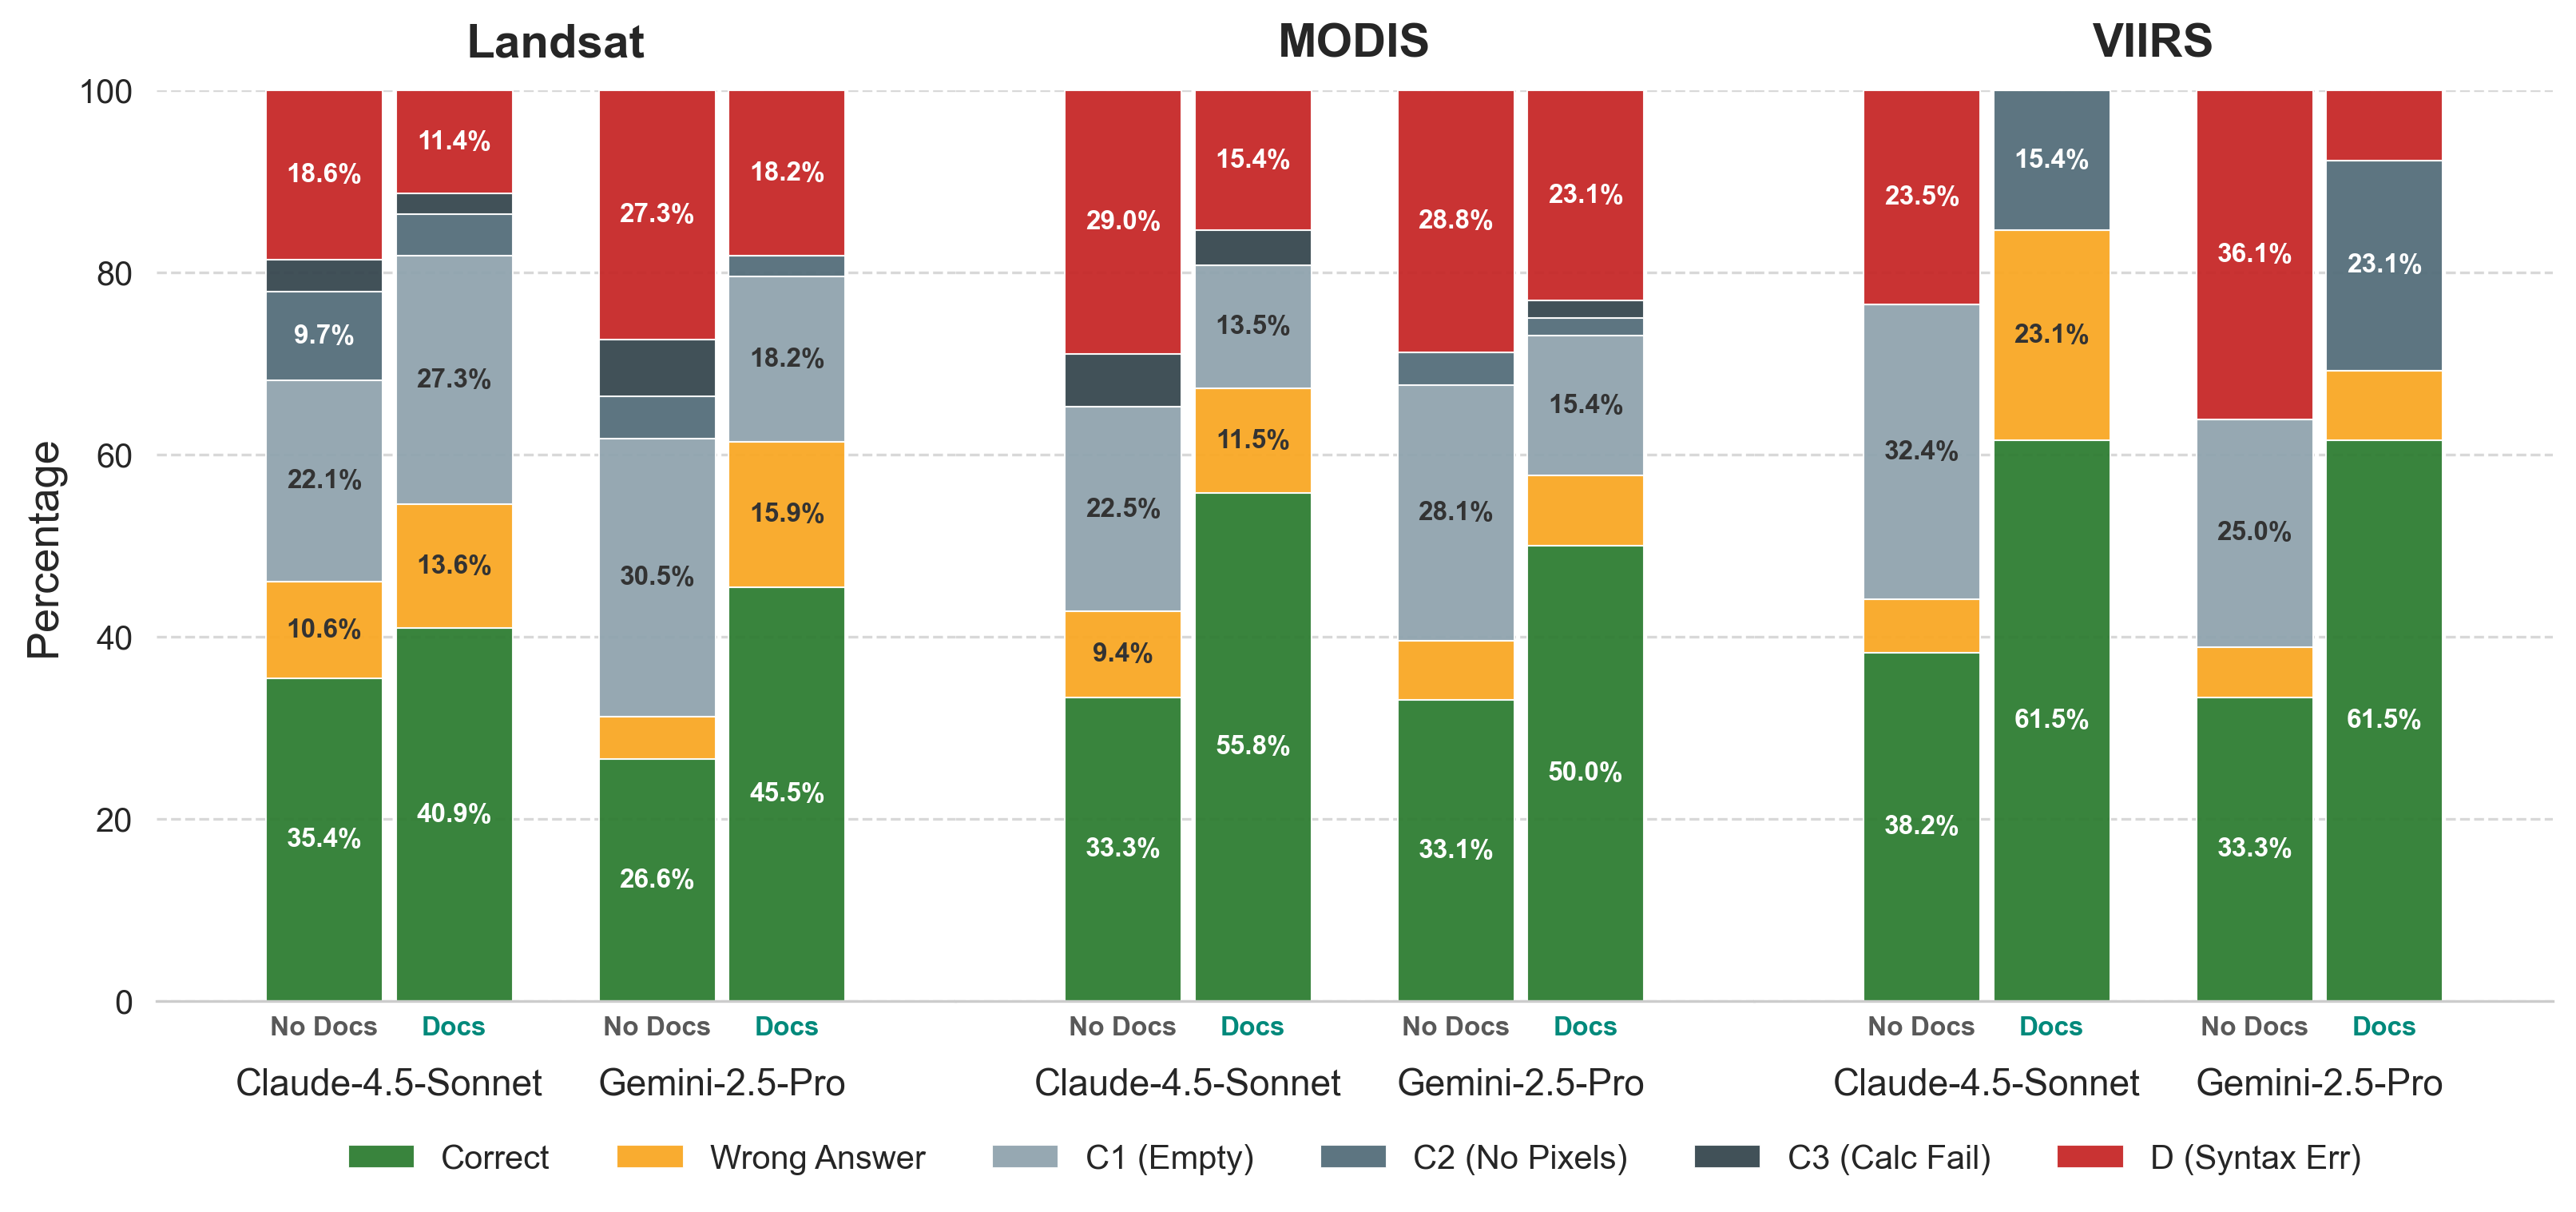

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION & DATA PREP ---

# Models
target_models = ['claude-sonnet-4-5-20250929', 'gemini-2.5-pro']
model_labels = ['Claude-4.5-Sonnet', 'Gemini-2.5-Pro']

# Modalities Order
modalities = ['landsat', 'modis', 'viirs']
modality_titles = {'landsat': 'Landsat', 'modis': 'MODIS', 'viirs': 'VIIRS'}

# Filter Data
df_target = df[df['code_llm'].isin(target_models)].copy()
df_target['code_llm'] = pd.Categorical(df_target['code_llm'], categories=target_models, ordered=True)

# Define Outcomes
def categorize_result(row):
    gt = row['gt_answer']
    pred = row['pred_code']
    if (gt == 'Yes' and pred == 'A') or (gt == 'No' and pred == 'B'): return 'Correct'
    elif pred in ['A', 'B']: return 'Wrong Answer'
    elif pred == 'C1': return 'C1 (Empty)'
    elif pred == 'C2': return 'C2 (No Pixels)'
    elif pred == 'C3': return 'C3 (Calc Fail)'
    elif pred == 'D':  return 'D (Syntax Err)'
    # return 'Unknown'

df_target['outcome'] = df_target.apply(categorize_result, axis=1)

# --- 2. COLOR PALETTES ---

doc_label_colors = {False: '#595959', True: '#00897B'} 

stack_colors = {
    'Correct':      '#2E7D32',
    'Wrong Answer': '#F9A825',
    'C1 (Empty)':   '#90A4AE',
    'C2 (No Pixels)':'#546E7A',
    'C3 (Calc Fail)':'#37474F',
    'D (Syntax Err)':'#C62828'
}
outcome_order = ['Correct', 'Wrong Answer', 'C1 (Empty)', 'C2 (No Pixels)', 'C3 (Calc Fail)', 'D (Syntax Err)']

# --- 3. DATA CALCULATION ---

stack_data = df_target.groupby(['modality', 'code_llm', 'documentation', 'outcome']).size().unstack(fill_value=0)
stack_pct = stack_data.div(stack_data.sum(axis=1), axis=0) * 100

for col in outcome_order:
    if col not in stack_pct.columns: 
        stack_pct[col] = 0

stack_pct = stack_pct[outcome_order]

# --- 4. PLOTTING ---

# Create Figure
fig, axes = plt.subplots(1, 3, figsize=(10, 5), dpi=300, sharey=True)
sns.set_style("whitegrid", {'axes.grid': False})

# Bar Layout Definitions
bar_width = 0.35
gap = 0.04 
indices = np.arange(len(target_models)) # [0, 1]

# Positions
pos_false = indices - (bar_width / 2) - (gap / 2)
pos_true  = indices + (bar_width / 2) + (gap / 2)

# Helper function
def plot_stack(axis, subset_df, positions, doc_key):
    try:
        data = subset_df.xs(doc_key, level='documentation')
    except KeyError:
        return 
        
    bottoms = np.zeros(len(data))
    
    for outcome in outcome_order:
        values = data[outcome].values
        if len(values) != len(positions): continue 

        axis.bar(
            positions, values, bottom=bottoms, width=bar_width, 
            label=outcome, 
            color=stack_colors[outcome], edgecolor='white', linewidth=0.5, alpha=0.95
        )
        
        for i, val in enumerate(values):
            if val > 8: 
                y_center = bottoms[i] + (val / 2)
                text_color = 'white' if outcome in ['Correct', 'D (Syntax Err)', 'C2 (No Pixels)', 'C3 (Calc Fail)'] else '#333333'
                axis.text(positions[i], y_center, f"{val:.1f}%", ha='center', va='center', 
                        color=text_color, fontsize=8, weight='bold')
        
        bottoms += values

# Loop through Modalities
for ax, mod in zip(axes, modalities):
    
    try:
        mod_subset = stack_pct.xs(mod, level='modality')
    except KeyError:
        ax.set_visible(False)
        continue

    plot_stack(ax, mod_subset, pos_false, False)
    plot_stack(ax, mod_subset, pos_true, True)
    
    ax.set_title(modality_titles[mod], fontsize=14, weight='bold', pad=10)
    ax.set_xticks(indices)
    ax.set_xticklabels(model_labels, fontsize=11, weight='medium')
    ax.set_xlabel('')
    ax.set_ylim(0, 100)
    
    # --- KEY CHANGE 1: Set X Limits ---
    # Since indices are 0 and 1, setting limits to -0.8 and 1.8 
    # creates extra whitespace on the left and right, centering the bars.
    ax.set_xlim(-0.7, 1.7)

    ax.grid(axis='y', linestyle='--', alpha=0.3, color='grey', zorder=0)
    ax.tick_params(axis='x', which='major', pad=20, length=0)
    
    # Custom Labels
    y_label_pos = -3
    for i in indices:
        ax.text(pos_false[i], y_label_pos, "No Docs", ha='center', va='center', 
                fontsize=8, color=doc_label_colors[False], weight='bold')
        ax.text(pos_true[i], y_label_pos, "Docs", ha='center', va='center', 
                fontsize=8, color=doc_label_colors[True], weight='bold')

axes[0].set_ylabel('Percentage', fontsize=13)

# --- 5. LEGEND & ADJUSTMENT ---

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles)) 

fig.legend(
    [by_label[k] for k in outcome_order], 
    outcome_order, 
    loc='lower center', 
    bbox_to_anchor=(0.5, -0.05), 
    ncol=6, 
    frameon=False,
    fontsize=10
)

sns.despine(left=True) 

# --- KEY CHANGE 2: Adjust Layout Spacing ---
# wspace=0.3 increases the horizontal gap between subplots
# bottom=0.15 ensures room for the legend
plt.subplots_adjust(bottom=0.12, wspace=0., left=0.0, right=1)

plt.savefig('./figures/stratified_modality.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
https://docs.google.com/spreadsheets/d/1Nqhjav4AJZFY8_0zH0X71TBp3q9q2RMvQcHymMupT8k/edit?usp=sharing

SyntaxError: invalid decimal literal (4250958575.py, line 1)